This is a file we will later on work on and push

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!python -m pip install statsmodels
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import MinMaxScaler
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('raw_data/methane_data.csv')

In [55]:
df.head()

,year,month,day,hour,minute,second,AN311,AN422,AN423,TP1721,RH1722,BA1723,TP1711,RH1712,BA1713,MM252,MM261,MM262,MM263,MM264,MM256,MM211,CM861,CR863,P_864,TC862,WM868,AMP1_IR,AMP2_IR,DMP3_IR,DMP4_IR,AMP5_IR,F_SIDE,V
0,2014,3,2,0,0,0,3.2,1.6,1.4,24.7,42,1097.2,27.3,54,1096.7,0.1,0.1,0.1,0.0,0.1,0.3,0.7,0.0,0,0.0,0.0,0.0,5.0,4.0,6.0,4.0,0.0,0.0,0.0
1,2014,3,2,0,0,1,3.2,1.6,1.4,24.7,42,1097.2,27.3,54,1096.7,0.1,0.1,0.1,0.0,0.1,0.3,0.7,0.0,0,0.0,0.0,0.0,5.0,4.0,5.0,4.0,0.0,0.0,0.0
2,2014,3,2,0,0,2,3.2,1.6,1.4,24.7,42,1097.2,27.3,54,1096.7,0.1,0.1,0.1,0.0,0.1,0.3,0.7,0.0,0,0.0,0.0,0.0,5.0,5.0,5.0,4.0,0.0,0.0,0.0
3,2014,3,2,0,0,3,3.2,1.6,1.4,24.7,42,1097.2,27.3,54,1096.7,0.1,0.1,0.1,0.0,0.1,0.3,0.7,0.0,0,0.0,0.0,0.0,5.0,5.0,5.0,4.0,0.0,0.0,0.0
4,2014,3,2,0,0,4,3.2,1.6,1.4,24.7,42,1097.2,27.3,54,1096.7,0.1,0.1,0.1,0.0,0.1,0.3,0.7,0.0,0,0.0,0.0,0.0,5.0,5.0,5.0,4.0,0.0,0.0,0.0


In [56]:
df.describe()

,year,month,day,hour,minute,second,AN311,AN422,AN423,TP1721,RH1722,BA1723,TP1711,RH1712,BA1713,MM252,MM261,MM262,MM263,MM264,MM256,MM211,CM861,CR863,P_864,TC862,WM868,AMP1_IR,AMP2_IR,DMP3_IR,DMP4_IR,AMP5_IR,F_SIDE,V
count,9199930.0,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06
mean,2014.0,4.301335e+00,1.486756e+01,1.147565e+01,2.949708e+01,2.949997e+01,3.483730e+00,1.654854e+00,1.497736e+00,2.547688e+01,4.928308e+01,1.106161e+03,2.889449e+01,6.868665e+01,1.105597e+03,3.809244e-02,4.944626e-02,5.067284e-02,2.484955e-01,3.274317e-01,4.297198e-01,6.995559e-01,3.292010e+01,7.508092e+01,8.696697e+01,2.989809e+01,1.802531e+00,5.853846e+00,5.741290e+00,4.200591e+00,3.969738e+00,4.143130e-01,9.374555e-02,1.346978e+00
std,0.0,1.031884e+00,8.713892e+00,6.920225e+00,1.731798e+01,1.731811e+01,6.105680e-01,1.282543e-01,3.304544e-01,9.320548e-01,6.142636e+00,7.625362e+00,7.568178e-01,7.267818e+00,7.616580e+00,1.213477e-01,1.250277e-01,1.357671e-01,1.973360e-01,2.055773e-01,2.036265e-01,1.508808e-01,2.139457e+01,5.516095e+01,2.915783e+01,9.898455e+00,1.319706e+00,2.441276e+01,2.425026e+01,1.734187e+01,1.731265e+01,1.096601e+01,2.914651e-01,5.996678e+00
min,2014.0,3.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-2.660000e+02,0.000000e+00,-2.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e-01,0.000000e+00,-2.000000e-01,-2.000000e+00,-2.000000e+00,0.000000e+00,-2.000000e+00,-2.000000e-01,-8.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-2.550000e+02,-2.550000e+02,-2.550000e+02,-2.550000e+02,-2.550000e+02,0.000000e+00,0.000000e+00
25%,2014.0,3.000000e+00,7.000000e+00,5.000000e+00,1.400000e+01,1.400000e+01,3.300000e+00,1.600000e+00,1.400000e+00,2.470000e+01,4.500000e+01,1.101000e+03,2.830000e+01,6.400000e+01,1.100500e+03,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e-01,2.000000e-01,3.000000e-01,6.000000e-01,2.000000e+00,3.100000e+01,9.340000e+01,3.240000e+01,5.000000e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2014.0,4.000000e+00,1.400000e+01,1.100000e+01,2.900000e+01,2.900000e+01,3.600000e+00,1.600000e+00,1.400000e+00,2.540000e+01,4.800000e+01,1.105900e+03,2.880000e+01,6.900000e+01,1.105300e+03,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e-01,3.000000e-01,4.000000e-01,7.000000e-01,4.370000e+01,7.800000e+01,9.420000e+01,3.290000e+01,2.200000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2014.0,5.000000e+00,2.200000e+01,1.700000e+01,4.400000e+01,4.400000e+01,3.800000e+00,1.700000e+00,1.500000e+00,2.610000e+01,5.400000e+01,1.109400e+03,2.940000e+01,7.400000e+01,1.108900e+03,0.000000e+00,1.000000e-01,1.000000e-01,3.000000e-01,4.000000e-01,5.000000e-01,8.000000e-01,4.890000e+01,1.030000e+02,9.570000e+01,3.350000e+01,2.790000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,2014.0,6.000000e+00,3.100000e+01,2.300000e+01,5.900000e+01,5.900000e+01,5.000000e+00,2.400000e+00,5.300000e+00,2.790000e+01,7.100000e+01,1.131700e+03,3.120000e+01,8.600000e+01,1.130900e+03,3.000000e+01,3.000000e+01,3.000000e+01,3.000000e+01,4.000000e+01,3.000000e+01,3.000000e+01,6.770000e+01,2.580000e+02,4.354000e+02,4.050000e+01,6.390000e+00,9.880000e+02,1.009000e+03,2.160000e+02,1.980000e+02,1.210000e+02,1.000000e+00,1.000000e+02


In [49]:
# picking 1 captor and preppint it for sarimax
methane_df = df[["year", "month", "day", "hour", "minute", "second", "MM261"]]
methane_df["datetime"] = pd.to_datetime(methane_df[["year", "month", "day", "hour", "minute", "second"]])
methane_df.head()

/var/folders/gy/hcvvbmvj4cq5xg6zlbdllgw80000gn/T/ipykernel_27694/2536682496.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  methane_df["datetime"] = pd.to_datetime(methane_df[["year", "month", "day", "hour", "minute", "second"]])


,year,month,day,hour,minute,second,MM261,datetime
0,2014,3,2,0,0,0,0.1,2014-03-02 00:00:00
1,2014,3,2,0,0,1,0.1,2014-03-02 00:00:01
2,2014,3,2,0,0,2,0.1,2014-03-02 00:00:02
3,2014,3,2,0,0,3,0.1,2014-03-02 00:00:03
4,2014,3,2,0,0,4,0.1,2014-03-02 00:00:04


In [50]:
print(methane_df.columns.tolist())

['year', 'month', 'day', 'hour', 'minute', 'second', 'MM261', 'datetime']


In [54]:
dayslist = methane_df["day"].nunique()
print(dayslist)

31


In [52]:
len(set(dayslist))

31

In [57]:
methane_df["day_ind"] = methane_df["datetime"].dt.dayofyear
methane_df.head()

/var/folders/gy/hcvvbmvj4cq5xg6zlbdllgw80000gn/T/ipykernel_27694/3403704721.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  methane_df["day_ind"] = methane_df["datetime"].dt.dayofyear


,year,month,day,hour,minute,second,MM261,datetime,day_ind
0,2014,3,2,0,0,0,0.1,2014-03-02 00:00:00,61
1,2014,3,2,0,0,1,0.1,2014-03-02 00:00:01,61
2,2014,3,2,0,0,2,0.1,2014-03-02 00:00:02,61
3,2014,3,2,0,0,3,0.1,2014-03-02 00:00:03,61
4,2014,3,2,0,0,4,0.1,2014-03-02 00:00:04,61


In [60]:
print(methane_df["day_ind"].unique())
len(methane_df["day_ind"].unique())

[ 61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78
  79  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96
  97  98  99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114
 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132
 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150
 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167]


107

In [8]:
# Creating the following features:
# reaching the threshold of xx methane concentration
# increase in concentration of methane
# increase acceleration of methane concentration

In [9]:
# définir un nouveau dataframe qui se focalise sur les évènements de concentration de méthane
low_range = 0.7
high_range = 5

In [10]:
# filtrer les jours où ça s'est produit
methane_df["event"] = methane_df["MM261"].apply(lambda x: 1 if low_range <= x <= high_range else 0)
methane_df.describe()

/var/folders/gy/hcvvbmvj4cq5xg6zlbdllgw80000gn/T/ipykernel_27694/4077469890.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  methane_df["event"] = methane_df["MM261"].apply(lambda x: 1 if low_range <= x <= high_range else 0)


,year,month,day,hour,minute,second,MM261,datetime,event
count,9199930.0,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9.199930e+06,9199930,9.199930e+06
mean,2014.0,4.301335e+00,1.486756e+01,1.147565e+01,2.949708e+01,2.949997e+01,4.944626e-02,2014-04-24 06:30:15.031896064,1.217401e-04
min,2014.0,3.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2014-03-02 00:00:00,0.000000e+00
25%,2014.0,3.000000e+00,7.000000e+00,5.000000e+00,1.400000e+01,1.400000e+01,0.000000e+00,2014-03-28 14:53:02.249999872,0.000000e+00
50%,2014.0,4.000000e+00,1.400000e+01,1.100000e+01,2.900000e+01,2.900000e+01,0.000000e+00,2014-04-24 06:46:04.500000,0.000000e+00
75%,2014.0,5.000000e+00,2.200000e+01,1.700000e+01,4.400000e+01,4.400000e+01,1.000000e-01,2014-05-20 21:39:06.750000128,0.000000e+00
max,2014.0,6.000000e+00,3.100000e+01,2.300000e+01,5.900000e+01,5.900000e+01,3.000000e+01,2014-06-16 12:32:09,1.000000e+00
std,0.0,1.031884e+00,8.713892e+00,6.920225e+00,1.731798e+01,1.731811e+01,1.250277e-01,NaN,1.103292e-02


In [11]:
methane_df["day_ind"] = methane_df["datetime"].dt.dayofyear
methane_df.head()

/var/folders/gy/hcvvbmvj4cq5xg6zlbdllgw80000gn/T/ipykernel_27694/3403704721.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  methane_df["day_ind"] = methane_df["datetime"].dt.dayofyear


,year,month,day,hour,minute,second,MM261,datetime,event,day_ind
0,2014,3,2,0,0,0,0.1,2014-03-02 00:00:00,0,61
1,2014,3,2,0,0,1,0.1,2014-03-02 00:00:01,0,61
2,2014,3,2,0,0,2,0.1,2014-03-02 00:00:02,0,61
3,2014,3,2,0,0,3,0.1,2014-03-02 00:00:03,0,61
4,2014,3,2,0,0,4,0.1,2014-03-02 00:00:04,0,61


In [12]:
methane_df_events = methane_df[methane_df["event"] == 1]
methane_df_events.head()

,year,month,day,hour,minute,second,MM261,datetime,event,day_ind
293358,2014,3,5,9,29,18,0.8,2014-03-05 09:29:18,1,64
293359,2014,3,5,9,29,19,0.8,2014-03-05 09:29:19,1,64
293360,2014,3,5,9,29,20,1.5,2014-03-05 09:29:20,1,64
293361,2014,3,5,9,29,21,1.5,2014-03-05 09:29:21,1,64
293362,2014,3,5,9,29,22,1.8,2014-03-05 09:29:22,1,64


In [13]:
methane_df_events.columns

Index(['year', 'month', 'day', 'hour', 'minute', 'second', 'MM261', 'datetime',
       'event', 'day_ind'],
      dtype='object')

In [14]:
methane_df_events_day = methane_df[["datetime", "day_ind", "hour", "minute", "MM261"]].value_counts()
methane_df_events_day.head()

datetime             day_ind  hour  minute  MM261
2014-03-02 00:00:00  61       0     0       0.1      1
2014-05-12 00:41:29  132      0     41      0.1      1
2014-05-12 00:41:23  132      0     41      0.1      1
2014-05-12 00:41:24  132      0     41      0.1      1
2014-05-12 00:41:25  132      0     41      0.1      1
Name: count, dtype: int64

In [15]:
methane_df_events["day_ind"].nunique()

16

In [16]:
methane_df_events["day_ind"].unique()

array([ 64,  71,  78,  86,  92,  97, 106, 114, 116, 118, 127, 134, 141,
       147, 157, 161], dtype=int32)

11:30AM - March 11th

So far the key takeaway is : 

On 1 methane captor, out of ~105 days, only 16 show such methane spikes.

During those 16 days, we observe only 1 "period" during which the spike is observed (see in the thread the insights)

I suggest we slice the datasets for only those days

In [17]:
methane_df_events["minute_of_day"] = methane_df_events["datetime"].dt.hour * 60 + methane_df_events["datetime"].dt.minute

/var/folders/gy/hcvvbmvj4cq5xg6zlbdllgw80000gn/T/ipykernel_27694/1685850175.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  methane_df_events["minute_of_day"] = methane_df_events["datetime"].dt.hour * 60 + methane_df_events["datetime"].dt.minute


In [18]:
# Sort by datetime first
df_events = methane_df_events.sort_values("datetime").copy()

# Compute time gap between consecutive event rows
df_events["time_gap"] = df_events["datetime"].diff()

In [19]:
df_events.head()

,year,month,day,hour,minute,second,MM261,datetime,event,day_ind,minute_of_day,time_gap
293358,2014,3,5,9,29,18,0.8,2014-03-05 09:29:18,1,64,569,NaT
293359,2014,3,5,9,29,19,0.8,2014-03-05 09:29:19,1,64,569,0 days 00:00:01
293360,2014,3,5,9,29,20,1.5,2014-03-05 09:29:20,1,64,569,0 days 00:00:01
293361,2014,3,5,9,29,21,1.5,2014-03-05 09:29:21,1,64,569,0 days 00:00:01
293362,2014,3,5,9,29,22,1.8,2014-03-05 09:29:22,1,64,569,0 days 00:00:01


In [28]:
# A new period starts when the gap exceeds a threshold (e.g. XX second)
s = 120
gap_threshold = pd.Timedelta(seconds=s)
df_events["period_id"] = (df_events["time_gap"] > gap_threshold).cumsum()

In [29]:
summary = df_events.groupby("period_id").agg(
    start=("datetime", "min"),
    end=("datetime", "max"),
    duration_seconds=("datetime", lambda x: (x.max() - x.min()).total_seconds()),
    max_concentration=("MM261", "max"),
    mean_concentration=("MM261", "mean"),
    num_measurements=("datetime", "count")
)
summary

,start,end,duration_seconds,max_concentration,mean_concentration,num_measurements
period_id,,,,,,
0,2014-03-05 09:29:18,2014-03-05 09:30:31,73.0,4.0,2.127778,36
1,2014-03-12 09:09:46,2014-03-12 09:11:49,123.0,2.2,1.752273,88
2,2014-03-19 07:56:16,2014-03-19 07:56:57,41.0,2.3,1.995238,42
3,2014-03-27 10:12:32,2014-03-27 10:14:39,127.0,2.2,1.721277,94
4,2014-04-02 10:01:01,2014-04-02 10:02:26,85.0,4.0,2.135294,34
5,2014-04-07 20:23:03,2014-04-07 20:23:28,25.0,2.2,1.907692,26
6,2014-04-16 10:28:31,2014-04-16 10:29:00,29.0,2.3,2.073333,30
7,2014-04-24 08:10:44,2014-04-24 08:12:57,133.0,2.2,1.717021,94
8,2014-04-26 13:05:05,2014-04-26 13:09:34,269.0,5.0,3.350000,244


In [30]:
import os
os.makedirs("processed_data", exist_ok=True)
summary.to_csv("processed_data/methane_events_summary.csv", index=False)

In [31]:
methane_df_events.head()

,year,month,day,hour,minute,second,MM261,datetime,event,day_ind,minute_of_day
293358,2014,3,5,9,29,18,0.8,2014-03-05 09:29:18,1,64,569
293359,2014,3,5,9,29,19,0.8,2014-03-05 09:29:19,1,64,569
293360,2014,3,5,9,29,20,1.5,2014-03-05 09:29:20,1,64,569
293361,2014,3,5,9,29,21,1.5,2014-03-05 09:29:21,1,64,569
293362,2014,3,5,9,29,22,1.8,2014-03-05 09:29:22,1,64,569


In [24]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [25]:
methane_df_events.to_excel("methane_events.xlsx", index=False)

In [26]:
df_subset.plot.scatter(x="day_ind", y="minute_of_day", c="MM261", cmap="YlOrRd", figsize=(14, 6), s=2)

NameError: name 'df_subset' is not defined

In [ ]:
df_subset = methane_df_events[["day_ind", "minute_of_day", "MM261"]]
df_subset.head()

,day_ind,minute_of_day,MM261
293358,64,569,0.8
293359,64,569,0.8
293360,64,569,1.5
293361,64,569,1.5
293362,64,569,1.8


In [ ]:
df_subset["minute_of_day"].nunique()

38

In [ ]:
df_subset["minute_of_day"].unique()

array([ 569,  570,  549,  550,  551,  476,  612,  613,  614,  601,  602,
       1223,  628,  629,  490,  491,  492,  785,  786,  787,  788,  789,
        796,  525,  526,  540,  541,  542,  626,  627,  563,  564,  565,
        527,  528,  552,  553,  547], dtype=int32)

/var/folders/gy/hcvvbmvj4cq5xg6zlbdllgw80000gn/T/ipykernel_62374/3540207464.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset["hour"] = df_subset["minute_of_day"] // 60


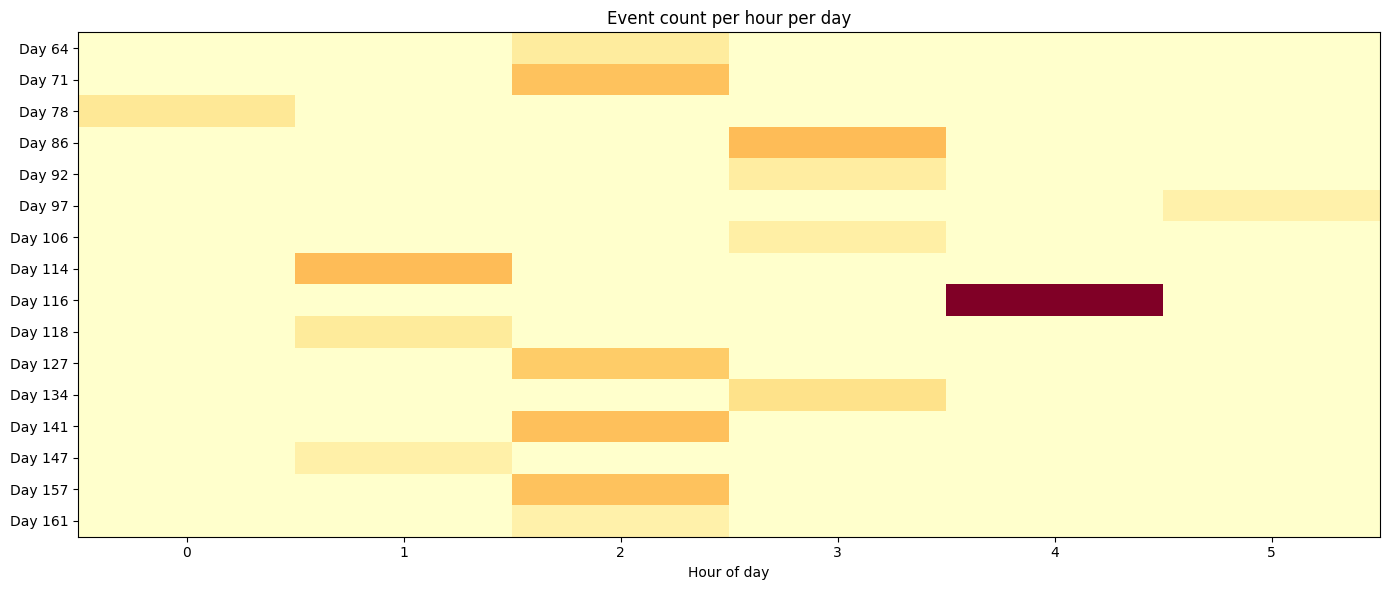

In [ ]:
df_subset["hour"] = df_subset["minute_of_day"] // 60
pivot = df_subset.groupby(["day_ind", "hour"]).size().unstack(fill_value=0)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(pivot, aspect="auto", cmap="YlOrRd")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f"Day {d}" for d in pivot.index])
ax.set_xlabel("Hour of day")
ax.set_title("Event count per hour per day")
plt.tight_layout()
plt.show()

<Axes: xlabel='datetime', ylabel='MM261'>

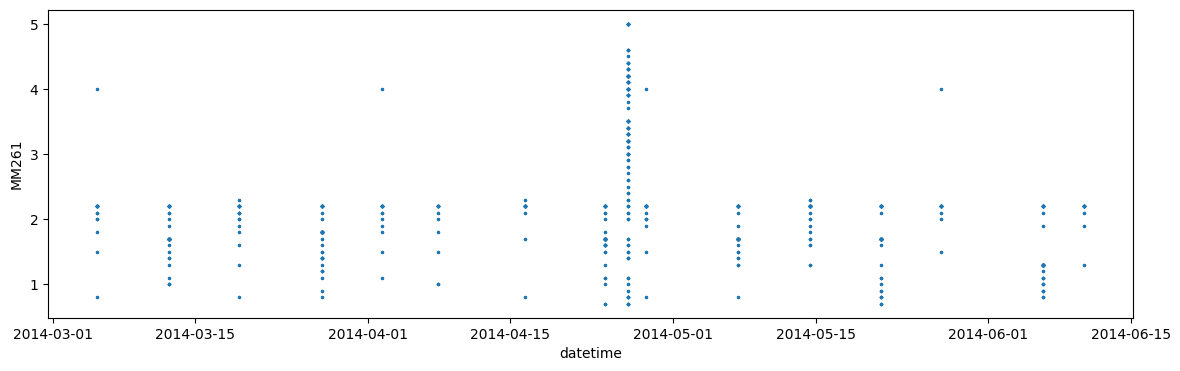

In [ ]:
met_df_events.plot(x="datetime", y="MM261", kind="scatter", figsize=(14, 4), s=2)

In [ ]:
# 1) identifier les jours pendants lesquels les évènements de concentration de méthane se sont produits
# 2) identifier la durée de ces évènements

In [ ]:
methane_df_events_day = methane_df_events.groupby("day_index")
methane_df_events_day.describe()

KeyError: 'day_index'

In [ ]:
m_t = 1.5
met_df_t["MM261"]
met_df_t["threshold_reached"] = (met_df_t["MM261"] >= m_t).astype(int)
met_df_t["conc_increase"] = met_df_t["MM261"].diff()
met_df_t["acc_increase"] = met_df_t["conc_increase"].diff()

In [ ]:
met_df_t.head()

,day,datetime,MM261,event,threshold_reached,conc_increase,acc_increase
0,2,2014-03-02 00:00:00,0.1,0,0,NaN,NaN
1,2,2014-03-02 00:00:01,0.1,0,0,0.0,NaN
2,2,2014-03-02 00:00:02,0.1,0,0,0.0,0.0
3,2,2014-03-02 00:00:03,0.1,0,0,0.0,0.0
4,2,2014-03-02 00:00:04,0.1,0,0,0.0,0.0


In [ ]:
met_df_t.describe()

,day,datetime,MM261,event,threshold_reached,conc_increase,acc_increase
count,9.199930e+06,9199930,9.199930e+06,9.199930e+06,9.199930e+06,9.199929e+06,9.199928e+06
mean,1.486756e+01,2014-04-24 06:30:15.031896064,4.944626e-02,1.217401e-04,1.571751e-04,-1.840330e-22,-1.327451e-22
min,1.000000e+00,2014-03-02 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,-1.800000e+01,-1.800000e+01
25%,7.000000e+00,2014-03-28 14:53:02.249999872,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.400000e+01,2014-04-24 06:46:04.500000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2.200000e+01,2014-05-20 21:39:06.750000128,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,3.100000e+01,2014-06-16 12:32:09,3.000000e+01,1.000000e+00,1.000000e+00,1.400000e+01,1.800000e+01
std,8.713892e+00,NaN,1.250277e-01,1.103292e-02,1.253597e-02,1.987862e-02,2.811509e-02


In [ ]:
{
  "anemometers": {
    "AN422": "airflow_headgate_ms",
    "AN423": "airflow_tailgate_ms",
    "AN311": "airflow_return_ms"
  },
  "environment_headgate_thp94": {
    "TP1711": "temperature_headgate_C",
    "RH1712": "humidity_headgate_pct",
    "BA1713": "barometer_headgate_hPa"
  },
  "environment_tailgate_thp93": {
    "TP1721": "temperature_tailgate_C",
    "RH1722": "humidity_tailgate_pct",
    "BA1723": "barometer_tailgate_hPa"
  },
  "methane_meters": {
    "MM252": "methane_return_pct",
    "MM261": "methane_tailgate_entry_pct",
    "MM262": "methane_face_pct",
    "MM263": "methane_target1_pct",
    "MM264": "methane_target2_pct",
    "MM256": "methane_target3_pct",
    "MM211": "methane_headgate_exit_pct"
  },
  "drainage_pipeline": {
    "CM861": "methane_high_conc_pct",
    "CR863": "drainage_pressure_diff_Pa",
    "P_864": "drainage_pressure_kPa",
    "TC862": "drainage_temperature_C",
    "WM868": "methane_delivery_m3min"
  },
  "shearer": {
    "AMP1_IR": "shearer_left_head_A",
    "AMP2_IR": "shearer_right_head_A",
    "DMP3_IR": "shearer_left_haulage_A",
    "DMP4_IR": "shearer_right_haulage_A",
    "AMP5_IR": "shearer_hydraulic_pump_A",
    "F_SIDE": "shearer_direction",
    "V": "shearer_speed_Hz"
  },
  "flat_mapping": {
    "AN311": "airflow_return_ms",
    "AN422": "airflow_headgate_ms",
    "AN423": "airflow_tailgate_ms",
    "TP1721": "temperature_tailgate_C",
    "RH1722": "humidity_tailgate_pct",
    "BA1723": "barometer_tailgate_hPa",
    "TP1711": "temperature_headgate_C",
    "RH1712": "humidity_headgate_pct",
    "BA1713": "barometer_headgate_hPa",
    "MM252": "methane_return_pct",
    "MM261": "methane_tailgate_entry_pct",
    "MM262": "methane_face_pct",
    "MM263": "methane_target1_pct",
    "MM264": "methane_target2_pct",
    "MM256": "methane_target3_pct",
    "MM211": "methane_headgate_exit_pct",
    "CM861": "methane_high_conc_pct",
    "CR863": "drainage_pressure_diff_Pa",
    "P_864": "drainage_pressure_kPa",
    "TC862": "drainage_temperature_C",
    "WM868": "methane_delivery_m3min",
    "AMP1_IR": "shearer_left_head_A",
    "AMP2_IR": "shearer_right_head_A",
    "DMP3_IR": "shearer_left_haulage_A",
    "DMP4_IR": "shearer_right_haulage_A",
    "AMP5_IR": "shearer_hydraulic_pump_A",
    "F_SIDE": "shearer_direction",
    "V": "shearer_speed_Hz"
  }
}


{'anemometers': {'AN422': 'airflow_headgate_ms',
  'AN423': 'airflow_tailgate_ms',
  'AN311': 'airflow_return_ms'},
 'environment_headgate_thp94': {'TP1711': 'temperature_headgate_C',
  'RH1712': 'humidity_headgate_pct',
  'BA1713': 'barometer_headgate_hPa'},
 'environment_tailgate_thp93': {'TP1721': 'temperature_tailgate_C',
  'RH1722': 'humidity_tailgate_pct',
  'BA1723': 'barometer_tailgate_hPa'},
 'methane_meters': {'MM252': 'methane_return_pct',
  'MM261': 'methane_tailgate_entry_pct',
  'MM262': 'methane_face_pct',
  'MM263': 'methane_target1_pct',
  'MM264': 'methane_target2_pct',
  'MM256': 'methane_target3_pct',
  'MM211': 'methane_headgate_exit_pct'},
 'drainage_pipeline': {'CM861': 'methane_high_conc_pct',
  'CR863': 'drainage_pressure_diff_Pa',
  'P_864': 'drainage_pressure_kPa',
  'TC862': 'drainage_temperature_C',
  'WM868': 'methane_delivery_m3min'},
 'shearer': {'AMP1_IR': 'shearer_left_head_A',
  'AMP2_IR': 'shearer_right_head_A',
  'DMP3_IR': 'shearer_left_haulage_A',